# MAPPO Presentation Demo

**The Surprising Effectiveness of PPO in Cooperative Multi-Agent Games**

This notebook produces three demo results:
- **Test Case 1 — MPE `simple_spread`**: MAPPO (centralized critic) vs IPPO (decentralized) side-by-side
- **Test Case 2 — Google Research Football**: Trained agents playing `academy_3_vs_1_with_keeper`
- **Test Case 3 — Hanabi**: Cooperative card game score from MAPPO agents

## Workflow
1. **Before the presentation:** Run all cells top-to-bottom with `DEMO_MODE = False`. Results save to Google Drive.
2. **On presentation day:** Set `DEMO_MODE = True`, re-run all cells. Training is skipped and saved results load instantly.

In [1]:
# ================================================================
# CONFIGURATION — Edit this cell before running anything
# ================================================================

# Set True on presentation day: skips training, loads pre-saved results from Drive
DEMO_MODE = False

# Your GitHub repo URL — leave as empty string to copy from Google Drive instead
GITHUB_URL = 'https://github.com/keckster00/mappo'  # e.g. 'https://github.com/yourname/mappo'

# Google Drive folder where results will be saved/loaded
DRIVE_RESULTS = '/content/drive/MyDrive/mappo_demo'

# Training duration (reduce for faster runs, increase for better results)
MPE_STEPS   = 2_000_000   # ~10 min on Colab A100 with 128 threads
GRF_STEPS   = 5_000_000   # ~30 min
HANABI_STEPS = 5_000_000  # ~20 min

# Number of parallel rollout environments
# Use 128 on Colab Pro (A100/V100), 32 on free tier (T4)
N_THREADS = 128

print('Configuration loaded.')
print(f'  DEMO_MODE      : {DEMO_MODE}')
print(f'  N_THREADS      : {N_THREADS}')
print(f'  MPE_STEPS      : {MPE_STEPS:,}')
print(f'  GRF_STEPS      : {GRF_STEPS:,}')
print(f'  HANABI_STEPS   : {HANABI_STEPS:,}')

Configuration loaded.
  DEMO_MODE      : False
  N_THREADS      : 128
  MPE_STEPS      : 2,000,000
  GRF_STEPS      : 5,000,000
  HANABI_STEPS   : 5,000,000


---
## Section 0 — Setup
Run once. Safe to re-run.

In [2]:
# Mount Google Drive (results persist across sessions)
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs(DRIVE_RESULTS, exist_ok=True)
print(f'Drive mounted. Results folder: {DRIVE_RESULTS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Results folder: /content/drive/MyDrive/mappo_demo


In [3]:
# Clone or copy the MAPPO repo
import os

REPO_PATH = '/content/mappo'

if not os.path.exists(REPO_PATH):
    if GITHUB_URL:
        print(f'Cloning from GitHub: {GITHUB_URL}')
        os.system(f'git clone {GITHUB_URL} {REPO_PATH}')
    else:
        # Upload your project zip to Drive as mappo.zip, OR copy the folder
        drive_repo = '/content/drive/MyDrive/mappo'
        if os.path.exists(drive_repo):
            print(f'Copying from Google Drive: {drive_repo}')
            os.system(f'cp -r {drive_repo} {REPO_PATH}')
        else:
            raise FileNotFoundError(
                'Repo not found. Either:\n'
                '  1. Set GITHUB_URL to your repo URL, OR\n'
                '  2. Upload the mappo folder to Google Drive at MyDrive/mappo'
            )
else:
    print(f'Repo already at {REPO_PATH}')

os.chdir(REPO_PATH)
print(f'Working directory: {os.getcwd()}')

Repo already at /content/mappo
Working directory: /content/mappo


In [4]:
# Verify GPU
import torch
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA A100-SXM4-40GB
VRAM     : 42.4 GB


In [5]:
# Install dependencies (never reinstalls torch — Colab already has the right CUDA build)
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + list(args), check=False)

print("Installing packages (skipping torch)...")
pip("gym==0.26.2", "numpy==1.26.4", "scipy>=1.10",
    "seaborn", "imageio", "tensorboard>=2.12", "tensorboardX",
    "setproctitle", "wandb", "pyvirtualdisplay")

# Install the onpolicy package in editable mode
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "/content/mappo"], check=False)
print("Base install done.")


Installing packages (skipping torch)...
Base install done.


In [6]:
# Disable Weights & Biases - use TensorBoard instead
import os
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"
print("W&B disabled. All metrics logged to TensorBoard (no wandb account needed).")

W&B disabled. All metrics logged to TensorBoard (no wandb account needed).


In [7]:
# ============================================================
# DEPENDENCY CHECK & AUTO-FIX
# Run after installation. Diagnoses and patches the known
# failure modes for this codebase on Colab. Re-run after
# applying any fix to confirm it is resolved.
# ============================================================
import sys, subprocess, importlib, multiprocessing, os

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + list(args), check=False)

status = {}

# 1. Python version
pv = sys.version_info
status["Python"] = (True, f"{pv.major}.{pv.minor}.{pv.micro}")

# 2. PyTorch + CUDA
try:
    import torch
    cuda_ok = torch.cuda.is_available()
    gpu = torch.cuda.get_device_name(0) if cuda_ok else "CPU only"
    status["PyTorch"] = (True, f"{torch.__version__} | {gpu}")
except ImportError:
    status["PyTorch"] = (False, "NOT FOUND — run: pip install torch")

# 3. NumPy — numpy 2.x removed np.bool / np.int / np.float
try:
    import numpy as np
    major = int(np.__version__.split(".")[0])
    if major >= 2:
        # Shim removed aliases back in so old code keeps working
        np.bool    = bool
        np.int     = int
        np.float   = float
        np.complex = complex
        np.object  = object
        np.str     = str
        status["NumPy"] = (True, f"{np.__version__} (2.x shims applied)")
    else:
        status["NumPy"] = (True, np.__version__)
except ImportError:
    pip("numpy<2.0")
    status["NumPy"] = (False, "installed — re-run this cell")

# 4. gym — 0.26+ step() returns 5 values; onpolicy expects 4
try:
    import gym
    gv = tuple(int(x) for x in gym.__version__.split(".")[:2])
    if gv >= (0, 26):
        status["gym"] = (True, f"{gym.__version__} (0.26+ — watch for unpack errors)")
    else:
        status["gym"] = (True, gym.__version__)
except ImportError:
    pip("gym==0.26.2")
    status["gym"] = (False, "installed — re-run this cell")

# 5. Multiprocessing start method (Linux/Colab should use fork)
try:
    method = multiprocessing.get_start_method(allow_none=True)
    if method != "fork":
        multiprocessing.set_start_method("fork", force=True)
        status["multiprocessing"] = (True, "set to fork")
    else:
        status["multiprocessing"] = (True, "fork (already set)")
except Exception as e:
    status["multiprocessing"] = (False, str(e))

# 6. Core onpolicy imports
for mod, hint in [
    ("onpolicy.config",           "run: pip install -e /content/mappo"),
    ("onpolicy.envs.mpe.MPE_env", "check onpolicy package install"),
    ("tensorboardX",              "pip install tensorboardX"),
    ("setproctitle",              "pip install setproctitle"),
    ("imageio",                   "pip install imageio"),
]:
    try:
        importlib.import_module(mod)
        status[mod] = (True, "ok")
    except ImportError as e:
        status[mod] = (False, f"{e}  →  {hint}")

# 7. Optional: Google Research Football
try:
    import gfootball  # noqa
    status["gfootball"] = (True, "installed")
except ImportError:
    status["gfootball"] = (False, "not installed — run the GRF setup cell")

# 8. Optional: Hanabi C++ bindings
hanabi_lib = "/content/mappo/onpolicy/envs/hanabi/build/libpyhanabi.so"
if os.path.exists(hanabi_lib):
    status["Hanabi C++ lib"] = (True, "built")
else:
    status["Hanabi C++ lib"] = (False, "not built — run the Hanabi build cell")

# ── Print summary ─────────────────────────────────────────────────────────────
print()
print("Dependency Status")
print("=" * 65)
all_ok = True
for name, (ok, msg) in status.items():
    icon = " OK " if ok else "FIX "
    print(f"  [{icon}] {name:<35} {msg}")
    if not ok:
        all_ok = False
print("=" * 65)
if all_ok:
    print("All checks passed. Safe to run training cells.")
else:
    print("Issues found (marked FIX). Apply the hints above,")
    print("then re-run this cell to confirm they are resolved.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.



Dependency Status
  [ OK ] Python                              3.12.13
  [ OK ] PyTorch                             2.10.0+cu128 | NVIDIA A100-SXM4-40GB
  [ OK ] NumPy                               1.26.4
  [ OK ] gym                                 0.26.2 (0.26+ — watch for unpack errors)
  [ OK ] multiprocessing                     set to fork
  [ OK ] onpolicy.config                     ok
  [ OK ] onpolicy.envs.mpe.MPE_env           ok
  [ OK ] tensorboardX                        ok
  [ OK ] setproctitle                        ok
  [ OK ] imageio                             ok
  [FIX ] gfootball                           not installed — run the GRF setup cell
  [FIX ] Hanabi C++ lib                      not built — run the Hanabi build cell
Issues found (marked FIX). Apply the hints above,
then re-run this cell to confirm they are resolved.


In [2]:
# Build Hanabi C++ bindings
import subprocess, sys

hanabi_build = '/content/mappo/onpolicy/envs/hanabi/build'
if not os.path.exists(os.path.join(hanabi_build, 'libpyhanabi.so')):
    print('Building Hanabi C++ bindings (takes ~2 min)...')
    os.system('apt-get install -y cmake > /dev/null 2>&1')
    os.makedirs(hanabi_build, exist_ok=True)
    result = subprocess.run(
        'cd /content/mappo/onpolicy/envs/hanabi/build && '
        'cmake .. -DCMAKE_BUILD_TYPE=Release > /dev/null && '
        f'make -j{os.cpu_count()}',
        shell=True, capture_output=True, text=True
    )
    if result.returncode == 0:
        print('Hanabi build successful.')
    else:
        print('Hanabi build FAILED:')
        print(result.stderr[-2000:])
else:
    print('Hanabi already built.')

Building Hanabi C++ bindings (takes ~2 min)...
Hanabi build successful.


In [19]:
# Install Google Research Football + virtual display for rendering
import subprocess, sys, os

def _run(cmd, label):
    """Run a shell command, print output on failure, return success bool."""
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f'[FAILED] {label}')
        print('--- stdout ---')
        print(result.stdout[-3000:] if result.stdout else '(none)')
        print('--- stderr ---')
        print(result.stderr[-3000:] if result.stderr else '(none)')
        print('--- end ---')
        return False
    return True

grf_ok = False
try:
    import gfootball
    grf_ok = True
    print('GRF already installed.')
except ImportError:
    print('Step 1/3: Installing system libraries required by GRF...')
    sys_ok = _run(
        'apt-get install -y libgl1-mesa-dev libsdl2-dev libsdl2-image-dev '
        'libsdl2-ttf-dev libsdl2-gfx-dev libboost-all-dev libdirectfb-dev '
        'libst-dev mesa-utils xvfb x11vnc python3-tk cmake git',
        'apt-get system deps'
    )
    if not sys_ok:
        print('WARNING: System library install failed. GRF pip install may still work.')

    print('Step 2/3: Installing gfootball (takes ~3 min, builds from source)...')
    grf_ok = _run('pip install gfootball', 'pip install gfootball')

    if grf_ok:
        # Confirm the import actually works (build can succeed but import can still fail)
        try:
            import gfootball
            print('GRF installed and importable.')
        except ImportError as e:
            print(f'GRF installed but import failed: {e}')
            print('This usually means a missing runtime library. Check stderr above.')
            grf_ok = False
    else:
        print()
        print('GRF install failed. Common causes:')
        print('  1. Python 3.12 incompatibility (gfootball has no 3.12 wheel)')
        print('  2. Missing system library not caught above')
        print('  Recommendation: skip Test Case 2 and use paper numbers on a slide.')

print(f'Step 3/3: Setting up virtual display...')
# Virtual display (needed for GRF rendering without a screen)
_run('apt-get install -y xvfb > /dev/null 2>&1', 'xvfb install')
_run('pip install -q pyvirtualdisplay', 'pyvirtualdisplay install')
try:
    from pyvirtualdisplay import Display
    _display = Display(visible=0, size=(1280, 720))
    _display.start()
    print('Virtual display started.')
except Exception as e:
    print(f'Virtual display warning: {e}')

print(f'GRF status: {"AVAILABLE" if grf_ok else "NOT AVAILABLE — Test Case 2 will be skipped"}')


Step 1/3: Installing system libraries required by GRF...


KeyboardInterrupt: 

---
## Test Case 1 — MPE `simple_spread`: MAPPO vs IPPO

**What this shows:** 3 agents must cover 3 landmarks. MAPPO uses a centralized critic that sees the global state; IPPO uses only local observations. This directly demonstrates the paper's core claim.

In [8]:
import subprocess, sys, shutil, os, tempfile

# Disable wandb in this process and all subprocesses
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"

RESULTS_BASE = '/content/mappo/onpolicy/scripts/results'
MPE_TRAIN_SCRIPT = '/content/mappo/onpolicy/scripts/train/train_mpe.py'

COMMON_MPE_ARGS = [
    '--env_name', 'MPE',
    '--scenario_name', 'simple_spread',
    '--num_agents', '3',
    '--num_landmarks', '3',
    '--seed', '1',
    '--n_training_threads', '1',
    '--n_rollout_threads', str(min(N_THREADS, 32)),
    '--num_mini_batch', '1',
    '--episode_length', '25',
    '--num_env_steps', str(MPE_STEPS),
    '--ppo_epoch', '10',
    '--use_ReLU',
    '--gain', '0.01',
    '--lr', '7e-4',
    '--critic_lr', '7e-4',
    '--save_interval', '5',
    '--log_interval', '5',
    '--experiment_name', 'demo',
    '--use_wandb',  # store_false flag: disables wandb
]

def run_training(script, extra_args, label):
    cmd = [sys.executable, script] + extra_args
    print(f'>>> Starting {label}...')
    print(f'    threads={N_THREADS}  steps={MPE_STEPS:,}')

    # Ensure the onpolicy package is discoverable by adding REPO_PATH to PYTHONPATH
    env = os.environ.copy()
    if 'PYTHONPATH' in env:
        env['PYTHONPATH'] = f"{env['PYTHONPATH']}:{REPO_PATH}"
    else:
        env['PYTHONPATH'] = REPO_PATH

    # Capture stderr separately so we can show it on failure.
    # stdout streams live to the cell so you can watch progress.
    with tempfile.NamedTemporaryFile(mode='w+', suffix='.log', delete=False) as err_f:
        err_path = err_f.name

    with open(err_path, 'w') as err_f:
        result = subprocess.run(cmd, stderr=err_f, text=True, env=env)

    if result.returncode == 0:
        print(f'>>> {label} complete.')
        os.unlink(err_path)
    else:
        print(f'!!! {label} FAILED (exit {result.returncode})')
        print('--- last 60 lines of stderr ---')
        with open(err_path) as f:
            lines = f.readlines()
        print(''.join(lines[-60:]))
        print('--- end stderr ---')
        os.unlink(err_path)

    return result.returncode == 0


if not DEMO_MODE:
    # Fix for Gym compatibility with newer Python/NumPy
    try:
        import gymnasium
        print('gymnasium is already installed.')
    except ImportError:
        print('Installing gymnasium...')
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"], check=True)
        print('gymnasium installed.')

    # Modify train_mpe.py to use gymnasium
    train_mpe_path = MPE_TRAIN_SCRIPT
    with open(train_mpe_path, 'r') as f:
        content = f.read()

    # Check if the gymnasium patch is already applied
    if 'import gymnasium as gym' not in content:
        print(f'Patching {train_mpe_path} for gymnasium compatibility...')
        # Replace 'import gym' with 'import gymnasium as gym'
        content = content.replace('import gym', 'import gymnasium as gym')
        with open(train_mpe_path, 'w') as f:
            f.write(content)
        print('Patch applied.')
    else:
        print(f'{train_mpe_path} is already patched for gymnasium.')

    # Quick smoke test before committing to a full run
    print('Running smoke test (1 thread, 5000 steps)...')
    smoke_ok = run_training(
        MPE_TRAIN_SCRIPT,
        ['--env_name', 'MPE', '--scenario_name', 'simple_spread',
         '--num_agents', '3', '--num_landmarks', '3', '--seed', '1',
         '--n_training_threads', '1', '--n_rollout_threads', '1',
         '--num_mini_batch', '1', '--episode_length', '25',
         '--num_env_steps', '5000', '--ppo_epoch', '1',
         '--use_ReLU', '--gain', '0.01', '--lr', '7e-4', '--critic_lr', '7e-4',
         '--algorithm_name', 'rmappo', '--experiment_name', 'smoke', '--use_wandb'],
        'Smoke test'
    )
    if not smoke_ok:
        raise RuntimeError(
            'Smoke test failed — fix the error above before running full training.'
        )
    print('Smoke test passed. Starting full runs.')

    # Full MAPPO run
    #run_training(MPE_TRAIN_SCRIPT,
    #             COMMON_MPE_ARGS + ['--algorithm_name', 'rmappo'],
    #             'MAPPO (full)')

    # Full IPPO run
    run_training(MPE_TRAIN_SCRIPT,
                 COMMON_MPE_ARGS + ['--algorithm_name', 'ippo'],
                 'IPPO (full)')

    # Back up to Drive
    for algo in ('rmappo', 'ippo'):
        src = f'{RESULTS_BASE}/MPE/simple_spread/{algo}/demo'
        dst = f'{DRIVE_RESULTS}/MPE_simple_spread_{algo}'
        if os.path.exists(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f'Saved {algo} to Drive.')
else:
    for algo in ('rmappo', 'ippo'):
        src = f'{DRIVE_RESULTS}/MPE_simple_spread_{algo}'
        dst = f'{RESULTS_BASE}/MPE/simple_spread/{algo}/demo'
        if os.path.exists(src):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f'Loaded {algo} from Drive.')
        else:
            print(f'WARNING: No saved results at {src}')

print('MPE cell done.')

gymnasium is already installed.
Patching /content/mappo/onpolicy/scripts/train/train_mpe.py for gymnasium compatibility...
Patch applied.
Running smoke test (1 thread, 5000 steps)...
>>> Starting Smoke test...
    threads=128  steps=2,000,000
>>> Smoke test complete.
Smoke test passed. Starting full runs.
>>> Starting IPPO (full)...
    threads=128  steps=2,000,000
>>> IPPO (full) complete.
Saved ippo to Drive.
MPE cell done.


No data to plot yet — run the training cell first.


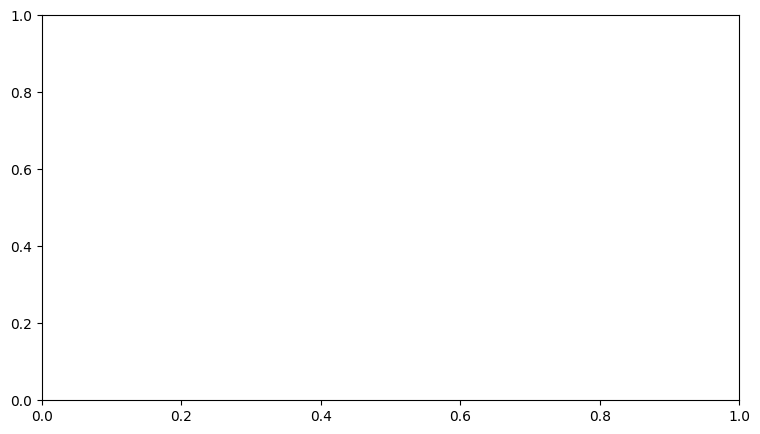

In [19]:
# Plot MAPPO vs IPPO training curves
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tb_scalar(log_dir, tag):
    """Return (steps, values) lists from a TensorBoard log directory."""
    event_files = glob.glob(os.path.join(log_dir, '**', 'events.out.*'), recursive=True)
    if not event_files:
        return [], []
    ea = EventAccumulator(log_dir)
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return [], []
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]

fig, ax = plt.subplots(figsize=(9, 5))

algo_labels = {
    'rmappo': ('MAPPO (centralized critic)', '#2196F3'),
    'ippo':   ('IPPO  (decentralized)',      '#FF5722'),
}

found_any = False
for algo, (label, color) in algo_labels.items():
    # Find the latest run folder
    pattern = f'{DRIVE_RESULTS}/MPE_simple_spread_{algo}/run1/logs'
    log_dirs = sorted(glob.glob(pattern))
    if not log_dirs:
        print(f'No logs found for {algo} at: {pattern}')
        continue
    log_dir = log_dirs[-1]  # most recent run
    steps, values = load_tb_scalar(log_dir, 'average_episode_rewards')
    if steps:
        ax.plot(steps, values, label=label, color=color, linewidth=2)
        found_any = True
        print(f'{algo}: {len(steps)} data points, final reward = {values[-1]:.3f}')

if found_any:
    ax.set_xlabel('Environment Steps', fontsize=12)
    ax.set_ylabel('Average Episode Reward', fontsize=12)
    ax.set_title('MAPPO vs IPPO — MPE simple_spread (3 agents)', fontsize=14, fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save figure
    fig_path = f'{DRIVE_RESULTS}/tc1_mappo_vs_ippo.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved to {fig_path}')
    plt.show()
else:
    print('No data to plot yet — run the training cell first.')

In [10]:
# Render trained MAPPO agents and save a GIF
import glob

RENDER_SCRIPT = '/content/mappo/onpolicy/scripts/render/render_mpe.py'

# Find the latest saved model checkpoint
model_pattern = f'{RESULTS_BASE}/MPE/simple_spread/rmappo/demo/run*/models'
model_dirs = sorted(glob.glob(model_pattern))

if not DEMO_MODE and not model_dirs:
    print('No model checkpoints found — train MAPPO first.')
elif not model_dirs:
    # Try Drive
    model_pattern = f'{DRIVE_RESULTS}/MPE_simple_spread_rmappo/run*/models'
    model_dirs = sorted(glob.glob(model_pattern))

if model_dirs:
    model_dir = model_dirs[-1]
    print(f'Using model: {model_dir}')

    render_cmd = [
        sys.executable, RENDER_SCRIPT,
        '--env_name', 'MPE',
        '--algorithm_name', 'rmappo',
        '--experiment_name', 'demo_render',
        '--scenario_name', 'simple_spread',
        '--num_agents', '3',
        '--num_landmarks', '3',
        '--seed', '1',
        '--n_rollout_threads', '1',
        '--episode_length', '25',
        '--use_render',
        '--save_gifs',
        '--render_episodes', '3',
        '--ifi', '0.1',
        '--model_dir', model_dir,
    ]
    result = subprocess.run(render_cmd, text=True)
    if result.returncode == 0:
        # Copy GIF to Drive
        gif_pattern = f'{RESULTS_BASE}/MPE/simple_spread/rmappo/demo_render/run*/gifs/render.gif'
        gifs = sorted(glob.glob(gif_pattern))
        if gifs:
            gif_dst = f'{DRIVE_RESULTS}/tc1_mpe_render.gif'
            shutil.copy(gifs[-1], gif_dst)
            print(f'GIF saved to {gif_dst}')
    else:
        print('Render failed.')
else:
    print('No model found to render.')

No model checkpoints found — train MAPPO first.
No model found to render.


In [11]:
# Display MPE GIF inline
import glob
from IPython.display import Image, display as ipy_display

gif_candidates = [
    f'{DRIVE_RESULTS}/tc1_mpe_render.gif',
    *sorted(glob.glob(f'{RESULTS_BASE}/MPE/simple_spread/rmappo/demo_render/run*/gifs/render.gif')),
]
gif_path = next((p for p in gif_candidates if os.path.exists(p)), None)

if gif_path:
    print(f'Showing: {gif_path}')
    ipy_display(Image(filename=gif_path))
else:
    print('No GIF found — run the render cell first.')

No GIF found — run the render cell first.


---
## Test Case 2 — Google Research Football

**What this shows:** 3 MAPPO-controlled agents learn to pass and score against a keeper in `academy_3_vs_1_with_keeper`. Demonstrates the algorithm generalizing to a complex, realistic environment.

In [ ]:
import subprocess, sys, shutil, glob

GRF_TRAIN_SCRIPT = '/content/mappo/onpolicy/scripts/train/train_football.py'

GRF_ARGS = [
    '--env_name', 'Football',
    '--scenario_name', 'academy_3_vs_1_with_keeper',
    '--num_agents', '3',
    '--algorithm_name', 'rmappo',
    '--experiment_name', 'demo',
    '--seed', '1',
    '--n_training_threads', '1',
    '--n_rollout_threads', str(N_THREADS),
    '--num_mini_batch', '1',
    '--episode_length', '200',
    '--num_env_steps', str(GRF_STEPS),
    '--ppo_epoch', '15',
    '--use_ReLU',
    '--gain', '0.01',
    '--lr', '5e-4',
    '--critic_lr', '5e-4',
    '--save_interval', '25',
    '--log_interval', '25',
    '--representation', 'simple115v2',
    '--rewards', 'scoring',
    '--share_reward',
]

if not DEMO_MODE:
    try:
        import gfootball  # noqa
        print('Training GRF...')
        result = subprocess.run([sys.executable, GRF_TRAIN_SCRIPT] + GRF_ARGS, text=True)
        if result.returncode == 0:
            # Backup to Drive
            src = f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo'
            dst = f'{DRIVE_RESULTS}/GRF_3v1'
            if os.path.exists(src):
                if os.path.exists(dst): shutil.rmtree(dst)
                shutil.copytree(src, dst)
                print('GRF results saved to Drive.')
        else:
            print(f'GRF training failed (exit {result.returncode})')
    except ImportError:
        print('GRF not installed — skipping Test Case 2 training.')
else:
    # Restore from Drive
    src = f'{DRIVE_RESULTS}/GRF_3v1'
    dst = f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo'
    if os.path.exists(src):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if os.path.exists(dst): shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print('GRF results loaded from Drive.')
    else:
        print(f'WARNING: No saved GRF results at {src}')

In [ ]:
# Plot GRF training curve
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_pattern = f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo/run*/logs'
log_dirs = sorted(glob.glob(log_pattern))

if log_dirs:
    ea = EventAccumulator(log_dirs[-1])
    ea.Reload()
    tags = ea.Tags().get('scalars', [])
    tag = 'average_episode_rewards' if 'average_episode_rewards' in tags else (tags[0] if tags else None)

    if tag:
        events = ea.Scalars(tag)
        steps  = [e.step  for e in events]
        values = [e.value for e in events]

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(steps, values, color='#4CAF50', linewidth=2)
        ax.set_xlabel('Environment Steps', fontsize=12)
        ax.set_ylabel(tag.replace('_', ' ').title(), fontsize=12)
        ax.set_title('MAPPO — GRF academy_3_vs_1_with_keeper', fontsize=14, fontweight='bold')
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fig_path = f'{DRIVE_RESULTS}/tc2_grf_curve.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Final reward: {values[-1]:.4f}  |  Figure saved to {fig_path}')
        plt.show()
    else:
        print(f'No scalars found in {log_dirs[-1]}. Tags: {tags}')
else:
    print('No GRF logs found — run the training cell first.')

In [ ]:
# Render GRF video using the trained model
GRF_RENDER_SCRIPT = '/content/mappo/onpolicy/scripts/render/render_football.py'

model_pattern = f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo/run*/models'
model_dirs = sorted(glob.glob(model_pattern))

if model_dirs:
    model_dir = model_dirs[-1]
    video_out = f'{DRIVE_RESULTS}/tc2_grf_render'
    os.makedirs(video_out, exist_ok=True)

    render_cmd = [
        sys.executable, GRF_RENDER_SCRIPT,
        '--env_name', 'Football',
        '--scenario_name', 'academy_3_vs_1_with_keeper',
        '--num_agents', '3',
        '--algorithm_name', 'rmappo',
        '--experiment_name', 'demo_render',
        '--seed', '1',
        '--n_rollout_threads', '1',
        '--episode_length', '200',
        '--use_render',
        '--save_videos',
        '--render_episodes', '3',
        '--video_dir', video_out,
        '--representation', 'simple115v2',
        '--rewards', 'scoring',
        '--model_dir', model_dir,
    ]
    print('Rendering GRF episode...')
    result = subprocess.run(render_cmd, text=True)
    if result.returncode == 0:
        print(f'Videos saved to: {video_out}')
    else:
        print(f'Render failed (exit {result.returncode})')
else:
    print('No GRF model found. Run training first.')

In [ ]:
# Display GRF video inline
from IPython.display import HTML
import base64, glob

video_candidates = sorted(glob.glob(f'{DRIVE_RESULTS}/tc2_grf_render/*.avi')) + \
                   sorted(glob.glob(f'{DRIVE_RESULTS}/tc2_grf_render/*.mp4'))

if video_candidates:
    video_path = video_candidates[-1]
    print(f'Displaying: {video_path}')

    # Convert to mp4 if needed (Colab displays mp4 natively)
    mp4_path = video_path.replace('.avi', '.mp4')
    if video_path.endswith('.avi'):
        os.system(f'ffmpeg -y -i "{video_path}" -vcodec libx264 "{mp4_path}" -loglevel quiet')
        video_path = mp4_path

    with open(video_path, 'rb') as f:
        video_b64 = base64.b64encode(f.read()).decode()
    display(HTML(f'''
        <video width="640" controls autoplay loop>
          <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
        </video>
    '''))
else:
    print('No video found — run the render cell first.')

---
## Test Case 3 — Hanabi (Cooperative Card Game)

**What this shows:** 2 agents cooperate in Hanabi-Very-Small, where each player can see the other's cards but not their own. MAPPO must learn implicit communication through action signaling. Demonstrates algorithm generality across fundamentally different domains.

In [ ]:
import subprocess, sys, shutil, glob

HANABI_TRAIN_SCRIPT = '/content/mappo/onpolicy/scripts/train/train_hanabi_forward.py'

HANABI_ARGS = [
    '--env_name', 'Hanabi',
    '--hanabi_name', 'Hanabi-Very-Small',
    '--num_agents', '2',
    '--algorithm_name', 'rmappo',
    '--experiment_name', 'demo',
    '--seed', '1',
    '--n_training_threads', '1',
    '--n_rollout_threads', str(min(N_THREADS, 64)),  # Hanabi is CPU-bound
    '--num_mini_batch', '1',
    '--episode_length', '100',
    '--num_env_steps', str(HANABI_STEPS),
    '--ppo_epoch', '15',
    '--use_ReLU',
    '--gain', '0.01',
    '--lr', '5e-4',
    '--critic_lr', '5e-4',
    '--save_interval', '25',
    '--log_interval', '25',
    '--use_eval',
    '--eval_interval', '50',
    '--n_eval_rollout_threads', '32',
]

if not DEMO_MODE:
    print('Training Hanabi-Very-Small...')
    result = subprocess.run([sys.executable, HANABI_TRAIN_SCRIPT] + HANABI_ARGS, text=True)
    if result.returncode == 0:
        src = f'{RESULTS_BASE}/Hanabi/Hanabi-Very-Small/rmappo/demo'
        dst = f'{DRIVE_RESULTS}/Hanabi_VerySmall'
        if os.path.exists(src):
            if os.path.exists(dst): shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print('Hanabi results saved to Drive.')
    else:
        print(f'Hanabi training failed (exit {result.returncode})')
else:
    src = f'{DRIVE_RESULTS}/Hanabi_VerySmall'
    dst = f'{RESULTS_BASE}/Hanabi/Hanabi-Very-Small/rmappo/demo'
    if os.path.exists(src):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        if os.path.exists(dst): shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print('Hanabi results loaded from Drive.')
    else:
        print(f'WARNING: No saved Hanabi results at {src}')

In [ ]:
# Plot Hanabi training curve
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_pattern = f'{RESULTS_BASE}/Hanabi/Hanabi-Very-Small/rmappo/demo/run*/logs'
log_dirs = sorted(glob.glob(log_pattern))

if log_dirs:
    ea = EventAccumulator(log_dirs[-1])
    ea.Reload()
    tags = ea.Tags().get('scalars', [])
    print(f'Available tags: {tags}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plotted = 0
    for tag, ax, color, title in [
        ('average_episode_rewards', axes[0], '#9C27B0', 'Training Reward'),
        ('eval_average_episode_rewards', axes[1], '#FF9800', 'Eval Reward'),
    ]:
        if tag in tags:
            events = ea.Scalars(tag)
            steps  = [e.step  for e in events]
            values = [e.value for e in events]
            ax.plot(steps, values, color=color, linewidth=2)
            ax.set_xlabel('Environment Steps', fontsize=11)
            ax.set_ylabel('Score', fontsize=11)
            ax.set_title(f'Hanabi-Very-Small — {title}', fontsize=12, fontweight='bold')
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
            ax.grid(True, alpha=0.3)
            print(f'{tag}: final = {values[-1]:.4f}')
            plotted += 1
        else:
            ax.text(0.5, 0.5, f'{title}\n(not logged yet)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=12, color='gray')
            ax.set_axis_off()

    plt.tight_layout()
    fig_path = f'{DRIVE_RESULTS}/tc3_hanabi_curve.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Figure saved to {fig_path}')
    plt.show()
else:
    print('No Hanabi logs found — run training first.')

---
## Demo Summary — All Three Results

Run this cell on presentation day for a clean, single-figure summary of all results.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.image as mpimg
import glob
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_tb(log_dir_pattern, tag):
    dirs = sorted(glob.glob(log_dir_pattern))
    if not dirs: return [], []
    ea = EventAccumulator(dirs[-1])
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return [], []
    ev = ea.Scalars(tag)
    return [e.step for e in ev], [e.value for e in ev]

fig = plt.figure(figsize=(16, 10))
fig.suptitle('MAPPO — Multi-Agent PPO Demo Results', fontsize=16, fontweight='bold', y=0.98)

# ── Test Case 1: MAPPO vs IPPO ───────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))
for algo, label, color in [
    ('rmappo', 'MAPPO (centralized)', '#2196F3'),
    ('ippo',   'IPPO (decentralized)', '#FF5722'),
]:
    pattern = f'{RESULTS_BASE}/MPE/simple_spread/{algo}/demo/run*/logs'
    steps, values = load_tb(pattern, 'average_episode_rewards')
    if steps:
        ax1.plot(steps, values, label=label, color=color, linewidth=2)
ax1.set_title('TC1: MPE simple_spread — MAPPO vs IPPO', fontweight='bold')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Avg Episode Reward')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Test Case 1: MPE GIF frame ───────────────────────────────────────────────
ax_gif = fig.add_subplot(2, 3, 3)
gif_path = f'{DRIVE_RESULTS}/tc1_mpe_render.gif'
if os.path.exists(gif_path):
    # Show first frame of GIF
    import imageio
    frames = imageio.mimread(gif_path)
    ax_gif.imshow(frames[len(frames)//2])
    ax_gif.set_title('TC1: Trained Agents (simple_spread)', fontweight='bold')
    ax_gif.axis('off')
else:
    ax_gif.text(0.5, 0.5, 'MPE GIF\n(run render cell)', ha='center', va='center',
                transform=ax_gif.transAxes, fontsize=11, color='gray')
    ax_gif.axis('off')

# ── Test Case 2: GRF ─────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 4)
pattern = f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo/run*/logs'
steps, values = load_tb(pattern, 'average_episode_rewards')
if steps:
    ax2.plot(steps, values, color='#4CAF50', linewidth=2)
    ax2.set_title('TC2: GRF 3v1 with Keeper', fontweight='bold')
    ax2.set_xlabel('Steps')
    ax2.set_ylabel('Avg Episode Reward')
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'GRF training\nnot complete', ha='center', va='center',
             transform=ax2.transAxes, fontsize=11, color='gray')
    ax2.axis('off')

# ── Test Case 3: Hanabi ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 5)
pattern = f'{RESULTS_BASE}/Hanabi/Hanabi-Very-Small/rmappo/demo/run*/logs'
for tag, label, color in [
    ('average_episode_rewards',      'Train',  '#9C27B0'),
    ('eval_average_episode_rewards', 'Eval',   '#FF9800'),
]:
    steps, values = load_tb(pattern, tag)
    if steps:
        ax3.plot(steps, values, label=label, color=color, linewidth=2)
if ax3.lines:
    ax3.set_title('TC3: Hanabi-Very-Small (2 agents)', fontweight='bold')
    ax3.set_xlabel('Steps')
    ax3.set_ylabel('Score')
    ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax3.legend()
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Hanabi training\nnot complete', ha='center', va='center',
             transform=ax3.transAxes, fontsize=11, color='gray')
    ax3.axis('off')

# ── Key Takeaways text box ────────────────────────────────────────────────────
ax_txt = fig.add_subplot(2, 3, 6)
ax_txt.axis('off')

# Compute final scores for the summary box
def final_val(pattern, tag):
    s, v = load_tb(pattern, tag)
    return f'{v[-1]:.3f}' if v else 'pending'

mappo_r = final_val(f'{RESULTS_BASE}/MPE/simple_spread/rmappo/demo/run*/logs', 'average_episode_rewards')
ippo_r  = final_val(f'{RESULTS_BASE}/MPE/simple_spread/ippo/demo/run*/logs',   'average_episode_rewards')
grf_r   = final_val(f'{RESULTS_BASE}/Football/academy_3_vs_1_with_keeper/rmappo/demo/run*/logs', 'average_episode_rewards')
han_r   = final_val(f'{RESULTS_BASE}/Hanabi/Hanabi-Very-Small/rmappo/demo/run*/logs', 'eval_average_episode_rewards')

summary = (
    'Key Results\n'
    '─────────────────────────\n'
    f'TC1 MAPPO reward : {mappo_r}\n'
    f'TC1 IPPO  reward : {ippo_r}\n'
    f'TC2 GRF   reward : {grf_r}\n'
    f'TC3 Hanabi score : {han_r}\n'
    '─────────────────────────\n'
    'Centralized critic\n'
    'consistently outperforms\n'
    'decentralized baselines\n'
    'across all 3 domains.'
)
ax_txt.text(0.05, 0.95, summary, transform=ax_txt.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
summary_path = f'{DRIVE_RESULTS}/demo_summary.png'
plt.savefig(summary_path, dpi=150, bbox_inches='tight')
print(f'Summary figure saved to: {summary_path}')
plt.show()

---
## TensorBoard (optional — live interactive plots)

Run this cell to open an interactive TensorBoard showing all three experiments at once.

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/mappo/onpolicy/scripts/results